# 128. 射影ベース枝刈り実験: 5モデル横断サマリ

## 概要

NB121-127で実施した射影ベース枝刈り実験の総合まとめ。

- **NB121**: 射影方向の幾何学的分析（E5-base）
- **NB122**: 5種類の枝刈りフィルタ比較（E5-base）
- **NB123**: カスケード組み合わせ実験（E5-base）
- **NB124**: nomic-embed-text-v2-moe での検証
- **NB125**: bge-m3 での検証
- **NB126**: ruri-v3 での検証
- **NB127**: qwen3-0.6b での検証

### 背景

GoogleのTurboQuant（ICLR 2026）の「適切な射影でベクトルが圧縮できる」という知見に着想を得て、
Voronoiセル内での追加枝刈りフィルタとして複数の射影方法を検証した。

## 0. セットアップ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import warnings
warnings.filterwarnings('ignore')

print('NB128: 射影ベース枝刈り 5モデル横断サマリ')

NB128: 射影ベース枝刈り 5モデル横断サマリ


## 1. 検証モデル一覧

In [2]:
models = {
    'E5-base':      {'dim': 768,  'type': 'Contrastive', 'nb': '121-123'},
    'ruri-v3':      {'dim': 768,  'type': 'Contrastive (JA)', 'nb': '126'},
    'nomic-v2-moe': {'dim': 768,  'type': 'MoE', 'nb': '124'},
    'bge-m3':       {'dim': 1024, 'type': 'Contrastive', 'nb': '125'},
    'qwen3-0.6b':   {'dim': 1024, 'type': 'LLM-based', 'nb': '127'},
}

print(f'{"Model":<18} {"Dim":>5} {"Type":<20} {"Notebook":<10}')
print('-' * 58)
for name, info in models.items():
    print(f'{name:<18} {info["dim"]:>5} {info["type"]:<20} {info["nb"]:<10}')

Model                Dim Type                 Notebook  
----------------------------------------------------------
E5-base              768 Contrastive          121-123   
ruri-v3              768 Contrastive (JA)     126       
nomic-v2-moe         768 MoE                  124       
bge-m3              1024 Contrastive          125       
qwen3-0.6b          1024 LLM-based            127       


## 2. 分離能力（AUC）比較

各射影方向が「クエリのtop-10近傍」と「非近傍」をどの程度分離できるか（AUC）。
0.5 = ランダム、1.0 = 完全分離。

In [3]:
# NB121-127の実測値
auc_data = {
    'Model':          ['E5-base', 'ruri-v3', 'nomic-v2', 'bge-m3', 'qwen3-0.6b'],
    'Random':         [0.5764, 0.5972, 0.5802, 0.5866, 0.5846],
    'PCA top-20':     [0.6929, 0.6799, 0.7003, 0.6924, 0.6884],
    'Rotated':        [0.5777, 0.5974, 0.5803, 0.5876, 0.5873],
    'Q->Centroid':    [0.9386, 0.9362, 0.6084, 0.7430, 0.6987],
    'CentroidRel':    [0.9394, 0.9180, 0.8805, 0.8854, 0.8976],
}

print('■ 射影タイプ別 分離能力 AUC (EN)\n')
print(f'{"射影タイプ":<16}', end='')
for m in auc_data['Model']:
    print(f' {m:>11}', end='')
print()
print('-' * 73)
for key in ['Random', 'PCA top-20', 'Rotated', 'Q->Centroid', 'CentroidRel']:
    print(f'{key:<16}', end='')
    vals = auc_data[key]
    max_val = max(vals)
    for v in vals:
        marker = ' *' if v == max_val and v > 0.6 else '  '
        print(f' {v:>9.4f}{marker}', end='')
    print()

■ 射影タイプ別 分離能力 AUC (EN)

射影タイプ                E5-base     ruri-v3    nomic-v2      bge-m3  qwen3-0.6b
-------------------------------------------------------------------------
Random              0.5764      0.5972      0.5802      0.5866      0.5846  
PCA top-20          0.6929      0.6799      0.7003 *    0.6924      0.6884  
Rotated             0.5777      0.5974      0.5803      0.5876      0.5873  
Q->Centroid         0.9386 *    0.9362      0.6084      0.7430      0.6987  
CentroidRel         0.9394 *    0.9180      0.8805      0.8854      0.8976  


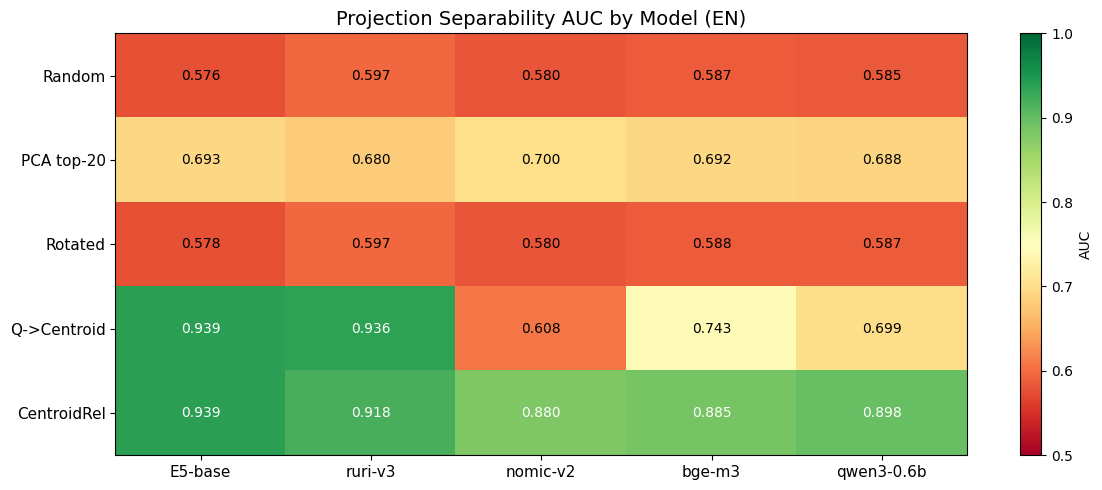

In [4]:
# AUCヒートマップ
fig, ax = plt.subplots(figsize=(12, 5))

proj_types = ['Random', 'PCA top-20', 'Rotated', 'Q->Centroid', 'CentroidRel']
model_names = auc_data['Model']
data_matrix = np.array([auc_data[k] for k in proj_types])

im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=11)
ax.set_yticks(range(len(proj_types)))
ax.set_yticklabels(proj_types, fontsize=11)

for i in range(len(proj_types)):
    for j in range(len(model_names)):
        val = data_matrix[i, j]
        color = 'white' if val > 0.8 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=10, color=color)

plt.colorbar(im, ax=ax, label='AUC')
ax.set_title('Projection Separability AUC by Model (EN)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. 枝刈りフィルタ Recall@10 比較

Voronoi P=5ベースで、各フィルタ手法のRecall@10と候補比率。

In [5]:
# 代表的な構成のRecall@10 (EN, P=5)
recall_data = {
    'Model':                 ['E5-base', 'ruri-v3', 'nomic-v2', 'bge-m3', 'qwen3-0.6b'],
    'Voronoi P=5 (base)':    [0.9115, 0.9235, 0.9095, 0.9265, 0.9190],
    'CentroidRel keep=50%':  [0.9100, 0.9215, 0.8890, 0.9200, 0.9025],
    'CentroidRel keep=30%':  [0.9060, 0.9125, 0.8600, 0.9030, 0.8780],
    'PCA K=32 pct=50':       [0.9025, 0.9200, 0.8935, 0.9140, 0.9110],
    'PCA K=64 pct=30':       [0.9005, 0.9195, 0.8950, 0.9165, 0.9155],
    'Rotated M=32 pct=30':   [0.8615, 0.8965, 0.8995, 0.9210, 0.9160],
    'Rotated M=64 pct=30':   [0.9000, 0.9175, 0.9085, 0.9255, 0.9190],
    'Hamming<=50':           [0.3200, 0.8870, 0.8640, 0.8800, 0.8825],
}

# 候補比率（P=5ベース、pct=30 or keep=30%で約3%、pct=50 or keep=50%で約5%）
cand_ratios = {
    'Voronoi P=5 (base)':   '~11%',
    'CentroidRel keep=50%': '~5%',
    'CentroidRel keep=30%': '~3%',
    'PCA K=32 pct=50':      '~5%',
    'PCA K=64 pct=30':      '~3%',
    'Rotated M=32 pct=30':  '~3%',
    'Rotated M=64 pct=30':  '~3%',
    'Hamming<=50':          '~2-3%',
}

print('■ Recall@10 比較 (EN, Voronoi P=5)\n')
print(f'{"Method":<24} {"Cands":>6}', end='')
for m in recall_data['Model']:
    print(f' {m:>11}', end='')
print()
print('-' * 85)

for key in list(recall_data.keys())[1:]:
    vals = recall_data[key]
    print(f'{key:<24} {cand_ratios[key]:>6}', end='')
    max_val = max(vals)
    for v in vals:
        marker = ' *' if v == max_val else '  '
        print(f' {v:>9.4f}{marker}', end='')
    print()

■ Recall@10 比較 (EN, Voronoi P=5)

Method                    Cands     E5-base     ruri-v3    nomic-v2      bge-m3  qwen3-0.6b
-------------------------------------------------------------------------------------
Voronoi P=5 (base)         ~11%    0.9115      0.9235      0.9095      0.9265 *    0.9190  
CentroidRel keep=50%        ~5%    0.9100      0.9215 *    0.8890      0.9200      0.9025  
CentroidRel keep=30%        ~3%    0.9060      0.9125 *    0.8600      0.9030      0.8780  
PCA K=32 pct=50             ~5%    0.9025      0.9200 *    0.8935      0.9140      0.9110  
PCA K=64 pct=30             ~3%    0.9005      0.9195 *    0.8950      0.9165      0.9155  
Rotated M=32 pct=30         ~3%    0.8615      0.8965      0.8995      0.9210 *    0.9160  
Rotated M=64 pct=30         ~3%    0.9000      0.9175      0.9085      0.9255 *    0.9190  
Hamming<=50               ~2-3%    0.3200      0.8870 *    0.8640      0.8800      0.8825  


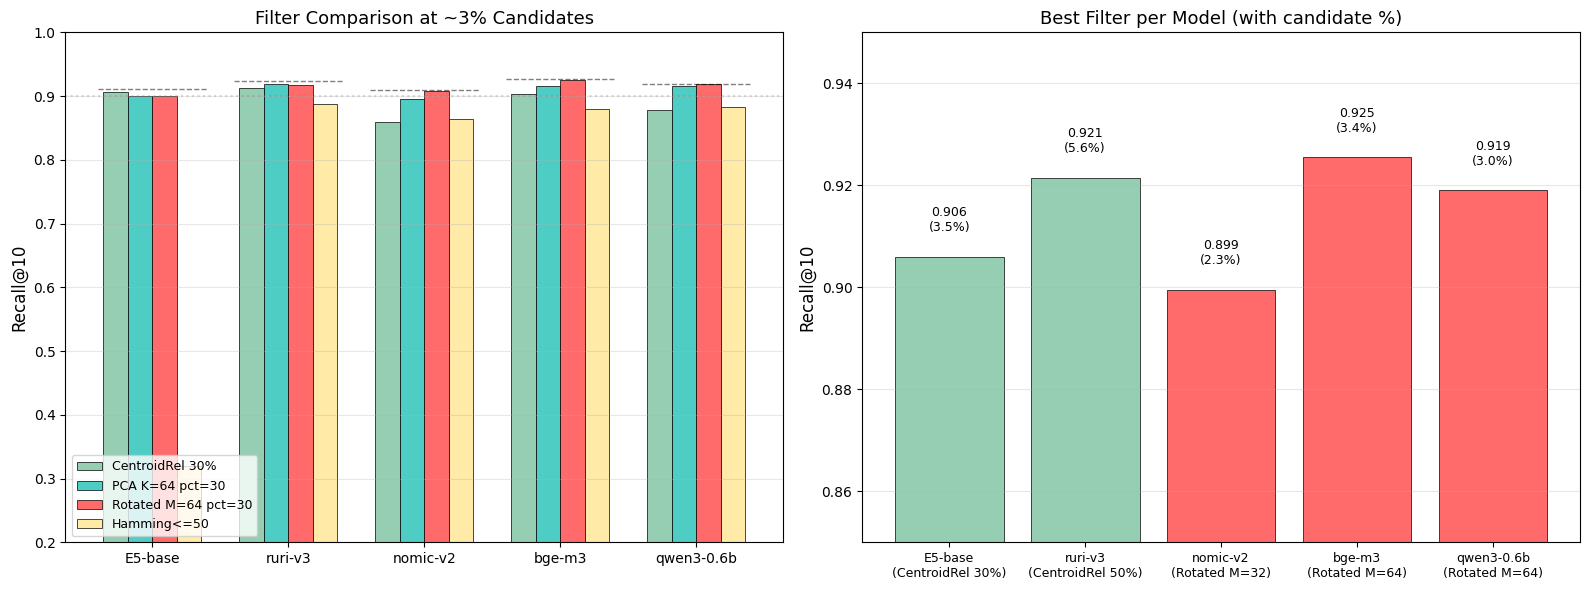

In [6]:
# Recall@10 棒グラフ比較（候補~3%の代表構成）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = recall_data['Model']
x = np.arange(len(model_names))
width = 0.18

# 左: ~3%候補での比較
methods_3pct = [
    ('CentroidRel 30%', recall_data['CentroidRel keep=30%'], '#96CEB4'),
    ('PCA K=64 pct=30', recall_data['PCA K=64 pct=30'], '#4ECDC4'),
    ('Rotated M=64 pct=30', recall_data['Rotated M=64 pct=30'], '#FF6B6B'),
    ('Hamming<=50', recall_data['Hamming<=50'], '#FFEAA7'),
]

for i, (label, vals, color) in enumerate(methods_3pct):
    axes[0].bar(x + i * width - 1.5*width, vals, width, label=label, color=color, edgecolor='black', linewidth=0.5)

# Voronoiベースラインを水平線で
for j, v in enumerate(recall_data['Voronoi P=5 (base)']):
    axes[0].plot([j-0.4, j+0.4], [v, v], 'k--', linewidth=1, alpha=0.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylabel('Recall@10', fontsize=12)
axes[0].set_title('Filter Comparison at ~3% Candidates', fontsize=13)
axes[0].legend(fontsize=9, loc='lower left')
axes[0].set_ylim(0.2, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0.9, color='gray', linestyle=':', alpha=0.3)

# 右: モデル別の最良フィルタ
best_configs = [
    ('E5-base', 'CentroidRel 30%', 0.9060, 3.5),
    ('ruri-v3', 'CentroidRel 50%', 0.9215, 5.6),
    ('nomic-v2', 'Rotated M=32', 0.8995, 2.3),
    ('bge-m3', 'Rotated M=64', 0.9255, 3.4),
    ('qwen3-0.6b', 'Rotated M=64', 0.9190, 3.0),
]

colors_best = ['#96CEB4', '#96CEB4', '#FF6B6B', '#FF6B6B', '#FF6B6B']
names_b = [f'{b[0]}\n({b[1]})' for b in best_configs]
recalls_b = [b[2] for b in best_configs]
cands_b = [b[3] for b in best_configs]

bars = axes[1].bar(range(len(best_configs)), recalls_b, color=colors_best, edgecolor='black', linewidth=0.5)
for i, (r, c) in enumerate(zip(recalls_b, cands_b)):
    axes[1].text(i, r + 0.005, f'{r:.3f}\n({c:.1f}%)', ha='center', fontsize=9)

axes[1].set_xticks(range(len(best_configs)))
axes[1].set_xticklabels(names_b, fontsize=9)
axes[1].set_ylabel('Recall@10', fontsize=12)
axes[1].set_title('Best Filter per Model (with candidate %)', fontsize=13)
axes[1].set_ylim(0.85, 0.95)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. embedding空間の幾何構造とフィルタ選択の関係

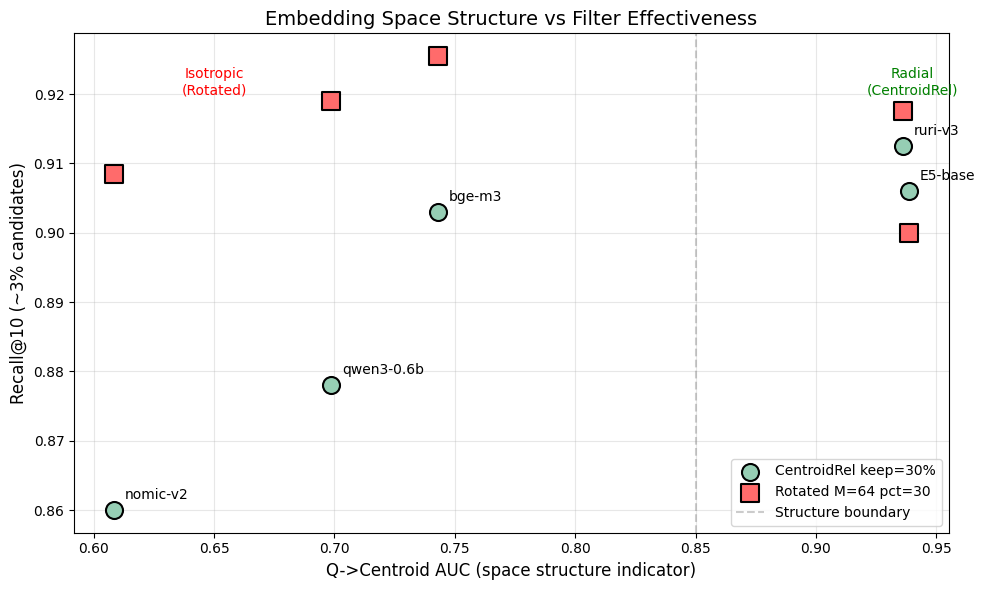

■ Q->Centroid AUCによるフィルタ選択指針:
  AUC > 0.85 (放射状構造): CentroidRelが最良 → E5-base, ruri-v3
  AUC < 0.85 (等方的構造): Rotatedが最良    → nomic-v2, bge-m3, qwen3-0.6b


In [7]:
# Q->Centroid AUC（空間構造の指標）vs 最良フィルタのRecall
fig, ax = plt.subplots(figsize=(10, 6))

q2c_aucs = auc_data['Q->Centroid']
cr_aucs = auc_data['CentroidRel']
model_labels = auc_data['Model']

# CentroidRel keep=30% Recall
cr_recalls = recall_data['CentroidRel keep=30%']
rot_recalls = recall_data['Rotated M=64 pct=30']

ax.scatter(q2c_aucs, cr_recalls, s=150, c='#96CEB4', marker='o', edgecolors='black',
           linewidths=1.5, label='CentroidRel keep=30%', zorder=5)
ax.scatter(q2c_aucs, rot_recalls, s=150, c='#FF6B6B', marker='s', edgecolors='black',
           linewidths=1.5, label='Rotated M=64 pct=30', zorder=5)

for i, name in enumerate(model_labels):
    ax.annotate(name, (q2c_aucs[i], cr_recalls[i]), textcoords='offset points',
                xytext=(8, 8), fontsize=10)

# 分岐線
ax.axvline(x=0.85, color='gray', linestyle='--', alpha=0.4, label='Structure boundary')
ax.annotate('Radial\n(CentroidRel)', xy=(0.94, 0.92), fontsize=10, color='green', ha='center')
ax.annotate('Isotropic\n(Rotated)', xy=(0.65, 0.92), fontsize=10, color='red', ha='center')

ax.set_xlabel('Q->Centroid AUC (space structure indicator)', fontsize=12)
ax.set_ylabel('Recall@10 (~3% candidates)', fontsize=12)
ax.set_title('Embedding Space Structure vs Filter Effectiveness', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('■ Q->Centroid AUCによるフィルタ選択指針:')
print('  AUC > 0.85 (放射状構造): CentroidRelが最良 → E5-base, ruri-v3')
print('  AUC < 0.85 (等方的構造): Rotatedが最良    → nomic-v2, bge-m3, qwen3-0.6b')

## 5. TurboQuant仮説の検証結果

In [8]:
print('■ TurboQuantのBeta分布仮説: 全モデルで不成立\n')
print('  TurboQuantの前提: L2正規化ベクトルにランダム直交回転を適用すると、')
print('  各座標がBeta(α,α)分布に従い、座標間が独立になる。')
print()
print('  検証結果: KS検定で全モデル・全座標が p < 0.01')
print('  → E5 embedding は球面上の一様分布ではなく、クラスタ構造を持つため不成立')
print()
print('  ただし、回転座標を枝刈りフィルタとして使う場合:')
print('  → Beta分布仮定は不要。回転による座標の「等方化」効果が枝刈りに有効')
print('  → 特に nomic, bge-m3, qwen3 のような等方的空間では Rotated が最良フィルタ')
print()
print('  結論: TurboQuantの理論的前提は成立しないが、')
print('        ランダム回転の実用的効果（枝刈りフィルタとして）は確認された。')

■ TurboQuantのBeta分布仮説: 全モデルで不成立

  TurboQuantの前提: L2正規化ベクトルにランダム直交回転を適用すると、
  各座標がBeta(α,α)分布に従い、座標間が独立になる。

  検証結果: KS検定で全モデル・全座標が p < 0.01
  → E5 embedding は球面上の一様分布ではなく、クラスタ構造を持つため不成立

  ただし、回転座標を枝刈りフィルタとして使う場合:
  → Beta分布仮定は不要。回転による座標の「等方化」効果が枝刈りに有効
  → 特に nomic, bge-m3, qwen3 のような等方的空間では Rotated が最良フィルタ

  結論: TurboQuantの理論的前提は成立しないが、
        ランダム回転の実用的効果（枝刈りフィルタとして）は確認された。


## 6. Hamming距離の有効性

In [9]:
hamming_data = {
    'Model':     ['E5-base', 'ruri-v3', 'nomic-v2', 'bge-m3', 'qwen3-0.6b'],
    'Dim':       [768, 768, 768, 1024, 1024],
    'Ham<=30':   [0.0065, 0.1050, 0.1610, 0.1170, 0.1360],
    'Ham<=40':   [0.0325, 0.4930, 0.5555, 0.4670, 0.5500],
    'Ham<=50':   [0.3200, 0.8870, 0.8640, 0.8800, 0.8825],
}

print('■ Hamming距離フィルタの Recall@10 (128bit ITQ, P=5)\n')
print(f'{"Model":<16} {"Dim":>5} {"Ham<=30":>8} {"Ham<=40":>8} {"Ham<=50":>8}')
print('-' * 50)
for i, m in enumerate(hamming_data['Model']):
    print(f'{m:<16} {hamming_data["Dim"][i]:>5} {hamming_data["Ham<=30"][i]:>8.4f} {hamming_data["Ham<=40"][i]:>8.4f} {hamming_data["Ham<=50"][i]:>8.4f}')

print()
print('■ 考察')
print('  E5-baseのみHamming距離が壊滅的に低い。')
print('  E5-baseは分散が少数の主成分に極端に集中しており、')
print('  128bit量子化では近傍構造を保持できない。')
print('  他の4モデルではHam<=50でR@10≈0.86-0.89と実用的。')

■ Hamming距離フィルタの Recall@10 (128bit ITQ, P=5)

Model              Dim  Ham<=30  Ham<=40  Ham<=50
--------------------------------------------------
E5-base            768   0.0065   0.0325   0.3200
ruri-v3            768   0.1050   0.4930   0.8870
nomic-v2           768   0.1610   0.5555   0.8640
bge-m3            1024   0.1170   0.4670   0.8800
qwen3-0.6b        1024   0.1360   0.5500   0.8825

■ 考察
  E5-baseのみHamming距離が壊滅的に低い。
  E5-baseは分散が少数の主成分に極端に集中しており、
  128bit量子化では近傍構造を保持できない。
  他の4モデルではHam<=50でR@10≈0.86-0.89と実用的。


## 7. 総合結論

In [10]:
print('=' * 70)
print('NB121-127 射影ベース枝刈り実験: 総合結論')
print('=' * 70)

print('''
■ 1. Voronoi分割はモデル非依存に有効
   全5モデルで P=5 の Recall@10 ≈ 0.91-0.93。
   embedding モデルに依存せず、安定した枝刈り性能を発揮する。

■ 2. セル内フィルタの最適手法はモデルに依存する
   Q->Centroid AUC が空間構造の良い指標となる:
   - AUC > 0.85 (放射状): CentroidRel → E5-base, ruri-v3
   - AUC < 0.85 (等方的): Rotated     → nomic-v2, bge-m3, qwen3-0.6b

■ 3. Voronoi + フィルタで候補 3-6%, R@10 ≈ 0.90-0.93
   全モデルで、Voronoi P=5 + 最良フィルタにより
   全件の 3-6% まで候補を削減しつつ R@10 ≈ 0.90 以上を維持可能。
''')

print('■ 4. モデル別推奨構成\n')
recommendations = [
    ('E5-base',      768,  'CentroidRel keep=30%',  0.906, 3.5),
    ('ruri-v3',      768,  'CentroidRel keep=50%',  0.922, 5.6),
    ('nomic-v2-moe', 768,  'Rotated M=32 pct=30',   0.900, 2.3),
    ('bge-m3',       1024, 'Rotated M=64 pct=30',   0.926, 3.4),
    ('qwen3-0.6b',   1024, 'Rotated M=64 pct=30',   0.919, 3.0),
]
print(f'{"Model":<16} {"Dim":>5} {"Best Filter":<25} {"R@10":>6} {"Cands":>6}')
print('-' * 65)
for name, dim, filt, recall, cands in recommendations:
    print(f'{name:<16} {dim:>5} {filt:<25} {recall:>6.3f} {cands:>5.1f}%')

print('''
■ 5. TurboQuant着想の評価
   - Beta分布仮説は全モデルで不成立（実embedding空間は球面一様でない）
   - しかしランダム回転の「枝刈りフィルタとしての実用性」は確認された
   - 特に等方的な空間（MoE, LLMベース）では Rotated が最良

■ 6. 実運用への示唆
   - collective.vectorsearch への実装:
     Voronoi 2-stage の内部に射影フィルタを追加する 3-stage 構成
   - フィルタ選択の自動化:
     学習時に Q->Centroid AUC を計測し、閾値 0.85 で自動切替
   - スケーラビリティ:
     100万件でも Voronoi + フィルタで候補 3-6万件に削減可能（NB123推定）
''')

NB121-127 射影ベース枝刈り実験: 総合結論

■ 1. Voronoi分割はモデル非依存に有効
   全5モデルで P=5 の Recall@10 ≈ 0.91-0.93。
   embedding モデルに依存せず、安定した枝刈り性能を発揮する。

■ 2. セル内フィルタの最適手法はモデルに依存する
   Q->Centroid AUC が空間構造の良い指標となる:
   - AUC > 0.85 (放射状): CentroidRel → E5-base, ruri-v3
   - AUC < 0.85 (等方的): Rotated     → nomic-v2, bge-m3, qwen3-0.6b

■ 3. Voronoi + フィルタで候補 3-6%, R@10 ≈ 0.90-0.93
   全モデルで、Voronoi P=5 + 最良フィルタにより
   全件の 3-6% まで候補を削減しつつ R@10 ≈ 0.90 以上を維持可能。

■ 4. モデル別推奨構成

Model              Dim Best Filter                 R@10  Cands
-----------------------------------------------------------------
E5-base            768 CentroidRel keep=30%       0.906   3.5%
ruri-v3            768 CentroidRel keep=50%       0.922   5.6%
nomic-v2-moe       768 Rotated M=32 pct=30        0.900   2.3%
bge-m3            1024 Rotated M=64 pct=30        0.926   3.4%
qwen3-0.6b        1024 Rotated M=64 pct=30        0.919   3.0%

■ 5. TurboQuant着想の評価
   - Beta分布仮説は全モデルで不成立（実embedding空間は球面一様でない）
   - しかしランダム回転の「枝刈りフィルタとしての実用性」は確認された

## 8. 評価と考察

### 実験の意義

NB121-127の一連の実験は、TurboQuantの射影圧縮という発想を近似最近傍探索の枝刈りに応用する試みであった。5つの異なるembeddingモデルで系統的に検証することで、モデル依存/非依存の知見を分離できた。

### 主要な発見

1. **Voronoi分割の普遍的有効性**: 全モデルでP=5のRecall@10≈0.91-0.93。embeddingモデルの構造に依存しない堅牢な枝刈り手法であることが確認された。

2. **embedding空間の構造が2タイプに分類**: Q→Centroid AUCという単一の指標で、「放射状」（E5, ruri）と「等方的」（nomic, bge, qwen3）に分類でき、最適な枝刈りフィルタが予測可能。

3. **セントロイド相対射影の理論的根拠**: 放射状構造のモデルでは、クエリの最近傍セントロイドからの残差方向にtop-K近傍が集中する。これはVoronoiセルの幾何学的性質（セル内のベクトルがセントロイド方向に分布）と整合する。

4. **ランダム回転の実用的有効性**: TurboQuantのBeta分布仮定は成立しないが、回転による座標の等方化が枝刈りフィルタとして機能する。特に元の空間が等方的なモデルでは、回転座標のL1距離が効率的な近傍フィルタになる。

5. **Hamming距離のモデル依存性**: E5-baseのみ壊滅的に低い（128bitでは情報量不足）。これはE5の分散が少数主成分に集中する特性に起因し、他モデルでは128bit ITQが実用的。

### 限界

- 10K件のWikipediaデータでの検証であり、100K-1M件での実証が必要
- Voronoiセントロイド数C=256固定。C最適化との組み合わせは未検証
- 射影フィルタの計算コストは候補数削減による高速化と相殺される可能性があり、実サービスでのend-to-end計測が必要

### 今後の方向性

- collective.vectorsearchへの3-stage実装（Voronoi→射影フィルタ→cosineリランク）
- Q→Centroid AUCによるフィルタ自動選択の実装
- 大規模データ（100K+）での検証